# Para esta Tarea
- Importación de un modelo con datos de ventas de casas (housing.csv)
- EDA completo siguiendo los modelos anteriores ○Feature engineering – estandarización, eliminación, nuevas columnas.
- Generación de variables dummy en el set de datos ○Aplicación de modelo de regresión lineal a la variable Price.
- Entrenamiento, evaluación y predicción de los resultados del modelo.
- Análisis de Sensibilidad e importancia de variables.
- Visualización de los resultados del modelo de regresión.

# Importacion de librerias

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Desarrollo

## EDA

In [48]:
df = pd.read_csv('../../../Archivos-Analisis/files-practica-m43/ANalista de Datos M43 - Housing.csv')

In [49]:
df.sample(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
285,4235000,6650,3,1,2,yes,yes,no,no,no,0,no,semi-furnished
226,4690000,5170,3,1,4,yes,no,no,no,yes,0,no,semi-furnished
167,5285000,4600,2,2,1,yes,no,no,no,yes,2,no,semi-furnished
130,5866000,4800,3,1,1,yes,yes,yes,no,no,0,no,unfurnished
101,6230000,5500,3,1,3,yes,no,no,no,no,1,yes,unfurnished
404,3493000,4900,3,1,2,no,no,no,no,no,0,no,unfurnished
420,3360000,4120,2,1,2,yes,no,no,no,no,0,no,unfurnished
38,7962500,6000,3,1,4,yes,yes,no,no,yes,2,no,unfurnished
17,8960000,8500,3,2,4,yes,no,no,no,yes,2,no,furnished
365,3703000,5450,2,1,1,yes,no,no,no,no,0,no,furnished


In [50]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [51]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [52]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4766729.25,1870439.62,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5150.54,2170.14,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.97,0.74,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.29,0.50,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.81,0.87,1.0,1.0,2.0,2.0,4.0
parking,545.0,0.69,0.86,0.0,0.0,0.0,1.0,3.0


In [53]:
df.nunique().sort_values()

mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
prefarea              2
furnishingstatus      3
bathrooms             4
stories               4
parking               4
bedrooms              6
price               219
area                284
dtype: int64

Insights
- Se deben de cambiar las columnas que tienen valores en cadena a numero (1, 0)
- Se debe cambiar furnishingstatus a 1 / 2/ 3
- Es un dataset completo

---

## Feature Engineering

In [59]:
# Cambio de valores a las columnas categoricas
df['mainroad'] = df['mainroad'].replace({'yes': 1, 'no': 0}, regex=True)
df['guestroom'] = df['guestroom'].replace({'yes': 1, 'no': 0}, regex=True)
df['basement'] = df['basement'].replace({'yes': 1, 'no': 0}, regex=True)
df['hotwaterheating'] = df['hotwaterheating'].replace({'yes': 1, 'no': 0}, regex=True)
df['airconditioning'] = df['airconditioning'].replace({'yes': 1, 'no': 0}, regex=True)
df['prefarea'] = df['prefarea'].replace({'yes': 1, 'no': 0}, regex=True)
df['furnishingstatus'] = df['furnishingstatus'].replace({'unfurnished': 3, 'semi-furnished': 2, 'furnished': 1}, regex=True)

In [60]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1


---

## Modelo de Regresion

In [61]:
# Importacion de las librerias necesarias para el modelo
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [64]:
# Creacion de la variable independiente
x = df.drop(['price'], axis=1)

# Creacion de la variable dependiente
y = df['price']

In [65]:
y.head(5)

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

In [66]:
# Hacemos la division de los datos en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.30, random_state=1)

In [67]:
# Regresor
regression_model = LinearRegression()

# Generamos el fit de regresion
regression_model.fit(x_train, y_train)

LinearRegression()

In [68]:
# Obtenemos el coeficion
regression_model.score(x_train, y_train)

0.6799674103626108

In [69]:
# Coeficiente de regresion del test
regression_model.score(x_test, y_test)

0.6621173401969211

---

## Resultados

In [70]:
y_pred = regression_model.predict(x_test)
df_pref = pd.DataFrame({'Actual': y_test, 'Prediccion': y_pred.round(2)})
df_pref

,Actual,Prediccion
62,7070000,6291567.11
247,4550000,6390833.35
142,5600000,6529768.58
107,6125000,5564502.05
483,2940000,4230599.25
...,...,...
450,3150000,4008865.09
542,1750000,2717347.44
408,3430000,2810959.56
80,6629000,5677214.47


In [71]:
# Otras Medidas de modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Suma absoluta de las diferencias
mae = mean_absolute_error(y_test, y_pred)
# Suma absoluta de las diferencias al cuadrado
mse = mean_squared_error(y_test, y_pred)
# Raiz de la suma absoluta de las diferencias al cuadrado
rmse = np.sqrt(mse)

In [72]:
print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squared error: {mse:.2f}')
print(f'Root Mean squared error: {rmse:.2f}')

Mean absolute error: 855894.77
Mean squared error: 1375329793553.13
Root Mean squared error: 1172744.56


In [73]:
# Obtenemos el coeficiente de la ecuacion
for index, col in enumerate(x_train.columns):
    print(f'Coeficiente de {col}: {regression_model.coef_[index]:.2f}')

Coeficiente de area: 246.35
Coeficiente de bedrooms: 47198.86
Coeficiente de bathrooms: 1020173.24
Coeficiente de stories: 525778.96
Coeficiente de mainroad: 476712.98
Coeficiente de guestroom: 275668.95
Coeficiente de basement: 557956.27
Coeficiente de hotwaterheating: 822714.56
Coeficiente de airconditioning: 608777.01
Coeficiente de parking: 274736.45
Coeficiente de prefarea: 500668.03
Coeficiente de furnishingstatus: -202462.67


In [ ]:
# Coeficiente de un DF
coeff_data = pd.DataFrame()

coeff_data = pd.concat([coeff_data, pd.DataFrame([{'Coeff': round(regression_model.intercept_, 2), 'Var': 'Intercept'}])], ignore_index=True)
    
# Coeficiente
for idx, col_name in enumerate(x_train.columns):
    coeff_data = pd.concat([coeff_data, pd.DataFrame([{'Coeff': round(regression_model.coef_[idx], 2), 'Var': col_name}])], ignore_index=True)
coeff_data

,Coeff,Var
0,315893.90,Intercept
1,246.35,area
2,47198.86,bedrooms
3,1020173.24,bathrooms
4,525778.96,stories
5,476712.98,mainroad
6,275668.95,guestroom
7,557956.27,basement
8,822714.56,hotwaterheating
9,608777.01,airconditioning


Text(0.5, 1.0, 'Comparacion de Valores Reales vs Predicciones')

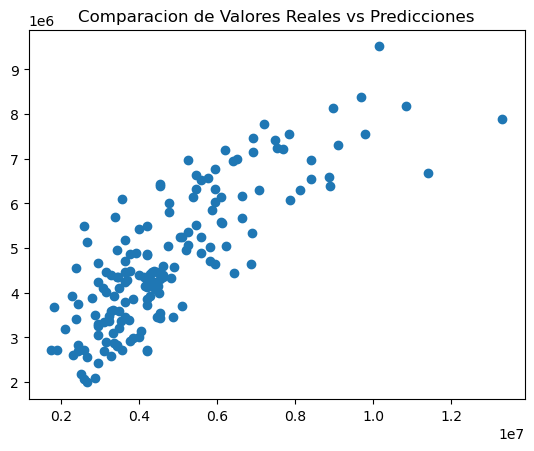

In [80]:
# Prediccion vs Valores Reales
predic = regression_model.predict(x_test)
plt.scatter(y_test, predic)
plt.title('Comparacion de Valores Reales vs Predicciones')

Text(0.5, 1.0, 'Histograma de Residuos')

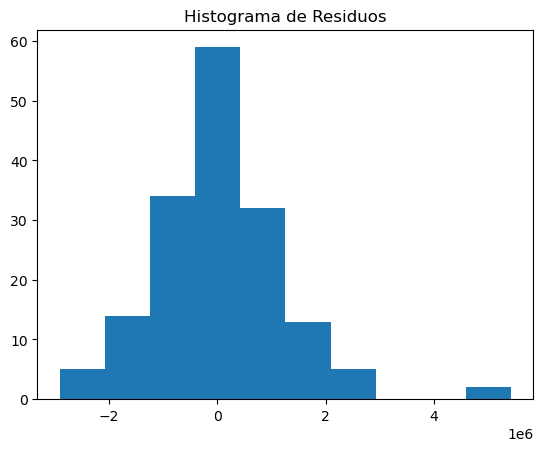

In [81]:
# Residuos
plt.hist(y_test - predic)
plt.title('Histograma de Residuos')

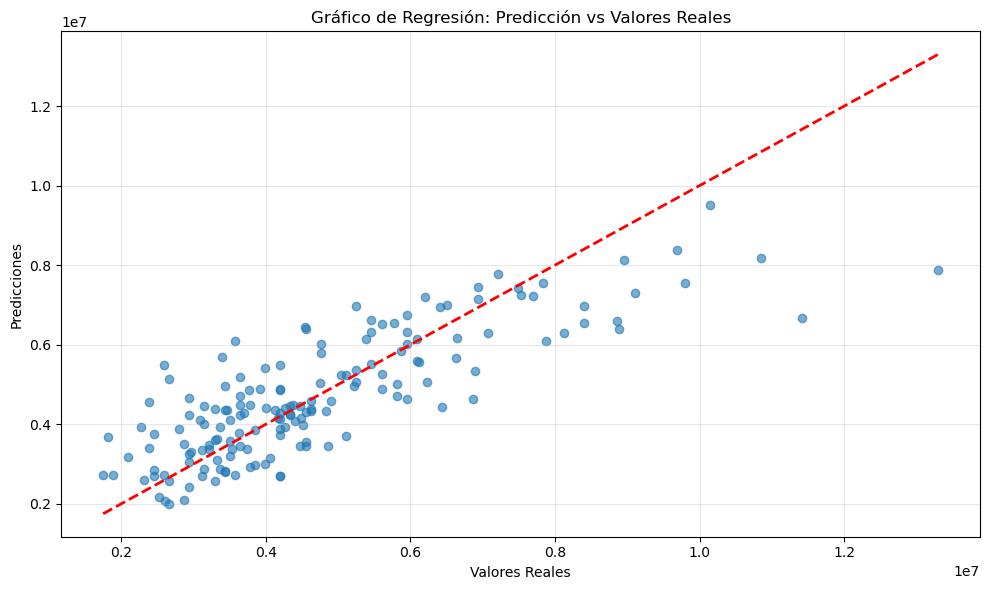

In [82]:
# Gráfico de regresión: Predicción vs Valores Reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Gráfico de Regresión: Predicción vs Valores Reales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()